# Model Training, Hyperparameter Tuning & Evaluation
## Breast Cancer Classification — Will the tumour be Malignant or Benign?

**Dataset:** `Breast_cancer_data.csv` (Wisconsin Breast Cancer, via Kaggle)  
- These measurements come from a Fine Needle Aspiration (FNA) biopsy — a doctor takes a tiny sample of cells from a breast lump and photographs them under a microscope. Software then measures geometric properties of the cell nuclei in the image.
**Target:** `diagnosis` — `0` = Malignant (cancerous), `1` = Benign (non-cancerous)  
**Task type:** Binary Classification

> **Why is this dataset great for learning?**  
> The classes are not perfectly separable, different models genuinely perform differently,
> and the stakes (medical diagnosis) make metric choices (precision vs recall) meaningful.

### What we cover
1. Exploratory Data Analysis
2. Feature Preprocessing
3. Training 3 models: Logistic Regression, Decision Tree, Random Forest
4. Classification Metrics: Accuracy, Precision, Recall, F1, ROC-AUC
5. Confusion Matrix
6. Model Comparison
7. Hyperparameter Tuning — GridSearchCV & RandomizedSearchCV
8. ROC Curves
9. Feature Importance

---
## 1. Import Libraries

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score, StratifiedKFold
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (9, 5)
RANDOM_STATE = 42

---
## 2. Load the Dataset

In [15]:
df = pd.read_csv('../data/Breast_cancer_data.csv')
print('Shape:', df.shape)
df.head()

Shape: (569, 6)


,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0
1,20.57,17.77,132.90,1326.0,0.08474,0
2,19.69,21.25,130.00,1203.0,0.10960,0
3,11.42,20.38,77.58,386.1,0.14250,0
4,20.29,14.34,135.10,1297.0,0.10030,0


In [16]:
# Readable labels for plots
df['diagnosis_label'] = df['diagnosis'].map({0: 'Malignant', 1: 'Benign'})

print('Class distribution:')
print(df['diagnosis_label'].value_counts())
print(f"\nMalignant: {(df['diagnosis']==0).sum()} | Benign: {(df['diagnosis']==1).sum()}")

Class distribution:
diagnosis_label
Benign       357
Malignant    212
Name: count, dtype: int64

Malignant: 212 | Benign: 357


---
## 3. Exploratory Data Analysis

Key questions:
- Are the classes balanced?
- Do features differ between Malignant and Benign tumours?
- Are features correlated with each other?

In [17]:
print('=== Missing values ===')
print(df.drop('diagnosis_label', axis=1).isnull().sum())

print('\n=== Summary statistics ===')
df.drop('diagnosis_label', axis=1).describe().round(3)

=== Missing values ===
mean_radius        0
mean_texture       0
mean_perimeter     0
mean_area          0
mean_smoothness    0
diagnosis          0
dtype: int64

=== Summary statistics ===


,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,diagnosis
count,569.000,569.000,569.000,569.000,569.000,569.000
mean,14.127,19.290,91.969,654.889,0.096,0.627
std,3.524,4.301,24.299,351.914,0.014,0.484
min,6.981,9.710,43.790,143.500,0.053,0.000
25%,11.700,16.170,75.170,420.300,0.086,0.000
50%,13.370,18.840,86.240,551.100,0.096,1.000
75%,15.780,21.800,104.100,782.700,0.105,1.000
max,28.110,39.280,188.500,2501.000,0.163,1.000


### 3.1 Class Distribution

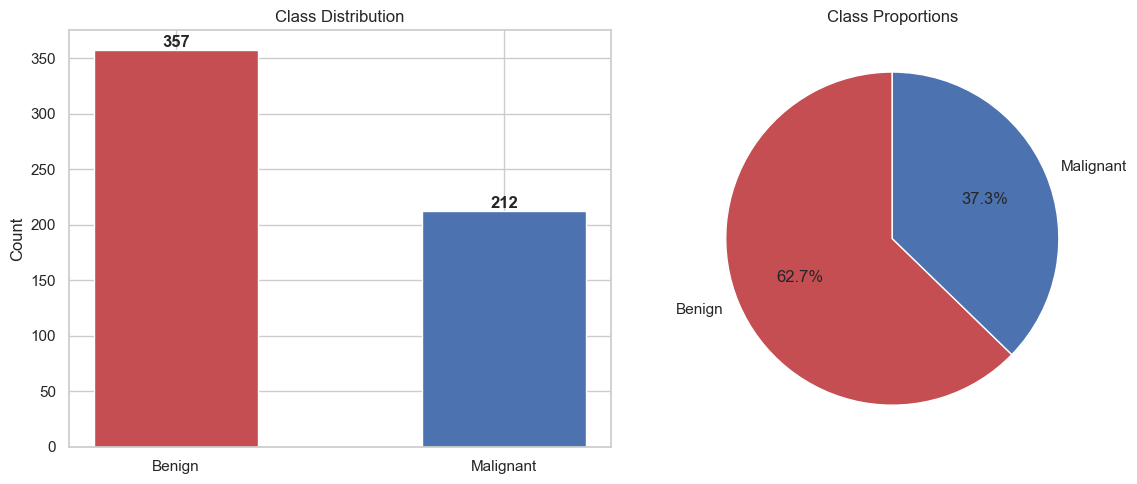

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

counts = df['diagnosis_label'].value_counts()
colors = ['#C44E52', '#4C72B0']

axes[0].bar(counts.index, counts.values, color=colors, width=0.5)
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 3, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=counts.index, colors=colors,
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Class Proportions')

plt.tight_layout()
plt.show()

### 3.2 Feature Distributions by Class

If a feature's distribution differs clearly between Malignant and Benign, it is informative for classification.

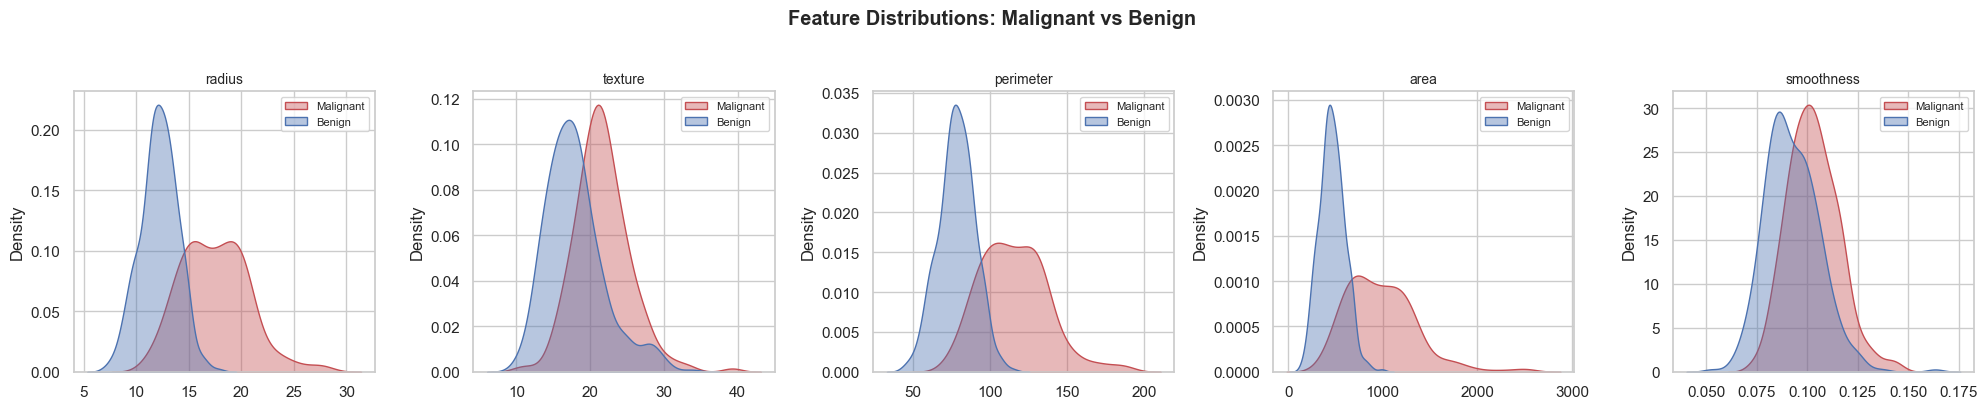

In [19]:
features = ['mean_radius', 'mean_texture', 'mean_perimeter', 'mean_area', 'mean_smoothness']

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for ax, feat in zip(axes, features):
    for label, color in [('Malignant', '#C44E52'), ('Benign', '#4C72B0')]:
        subset = df[df['diagnosis_label'] == label][feat]
        sns.kdeplot(subset, ax=ax, color=color, fill=True, alpha=0.4, label=label)
    ax.set_title(feat.replace('mean_', ''), fontsize=10)
    ax.set_xlabel('')
    ax.legend(fontsize=8)

plt.suptitle('Feature Distributions: Malignant vs Benign', y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. Preprocessing & Train-Test Split

All features are numerical → we apply `StandardScaler`.  
We use **stratified splitting** to preserve the class ratio in both sets.

In [22]:
X = df[features]
y = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y  # keeps class ratio
)

print(f'Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples')
print(f'Train class ratio — Malignant: {(y_train==0).sum()} | Benign: {(y_train==1).sum()}')
print(f'Test  class ratio — Malignant: {(y_test==0).sum()}  | Benign: {(y_test==1).sum()}')

Train: 455 samples | Test: 114 samples
Train class ratio — Malignant: 170 | Benign: 285
Test  class ratio — Malignant: 42  | Benign: 72


---
## 5. Model Training

We train three models that build on each other in complexity.

| Model | Approach | Key Strength |
|---|---|---|
| **Logistic Regression** | Linear decision boundary | Fast, interpretable, good baseline |
| **Decision Tree** | Recursive feature splits | Transparent — you can visualise the rules |
| **Random Forest** | Ensemble of many trees | Reduces the variance of a single tree |

The progression is deliberate: Decision Tree is the building block of Random Forest.  
Each model is wrapped in a Pipeline: `StandardScaler → Model`.

### Understanding Classification Metrics

Before training, let's clarify what we're measuring:

```
              Predicted Malignant   Predicted Benign
Actual Malignant    TP                  FN   ← False Negative: missed cancer!
Actual Benign       FP                  TN
```

- **Accuracy** = (TP + TN) / Total — overall correct predictions
- **Precision** = TP / (TP + FP) — "of all predicted malignant, how many actually were?"
- **Recall** = TP / (TP + FN) — "of all actual malignant, how many did we catch?"
- **F1** = harmonic mean of Precision and Recall
- **ROC-AUC** = area under the ROC curve (1.0 = perfect, 0.5 = random)

> **In medical diagnosis**: High **Recall** is critical — missing a cancer (FN) is far worse than a false alarm (FP).

In [23]:
def evaluate_model(name, pipeline, X_tr, y_tr, X_te, y_te):
    pipeline.fit(X_tr, y_tr)
    y_pred = pipeline.predict(X_te)
    y_prob = pipeline.predict_proba(X_te)[:, 1] if hasattr(pipeline.steps[-1][1], 'predict_proba') else None

    metrics = {
        'Model':     name,
        'Accuracy':  accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred),
        'Recall':    recall_score(y_te, y_pred),
        'F1':        f1_score(y_te, y_pred),
        'ROC-AUC':   roc_auc_score(y_te, y_prob) if y_prob is not None else None
    }
    return metrics, y_pred, y_prob, pipeline

print('Evaluation helper ready.')

Evaluation helper ready.


### 5.1 Logistic Regression

In [24]:
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000))
])

lr_metrics, y_pred_lr, y_prob_lr, lr_pipe = evaluate_model(
    'Logistic Regression', lr_pipe, X_train, y_train, X_test, y_test
)
print(classification_report(y_test, y_pred_lr, target_names=['Malignant', 'Benign']))

              precision    recall  f1-score   support

   Malignant       0.76      0.90      0.83        42
      Benign       0.94      0.83      0.88        72

    accuracy                           0.86       114
   macro avg       0.85      0.87      0.85       114
weighted avg       0.87      0.86      0.86       114



Columns and	What it answers

* support	- count of actual samples - How many Malignant cases were in the test set?	42 actual Malignant
* precision - TP / (TP + FP)- Of all the tumours the model predicted as Malignant — how many truly were?	76% were correct
* recall - TP / (TP + FN) - Of all actual Malignant tumours — how many did the model catch?	90% were caught
* f1-score - 2 × (P × R) / (P + R) - Balance between precision and recall	0.83

For cancer diagnosis: Recall is the most important.

A recall of 0.90 means the model missed 10% of real cancer cases — those go undetected.

A low precision means some healthy patients get a false alarm — bad, but not as dangerous.

Row and What it means

* accuracy - Overall: 86% of all 114 predictions were correct (regardless of class)
* macro avg - Simple average of Malignant + Benign metrics — treats both classes equally
* weighted avg - Average weighted by support (72 Benign vs 42 Malignant) — Benign contributes more because there are more of them

### 5.2 Decision Tree Classifier

A Decision Tree splits the data on one feature at a time, choosing the split that best separates the classes.

```
Is mean_radius <= 15.1?
    ├── Yes → Is mean_texture <= 21.3? → ...
    └── No  → Predict: Malignant
```

Key hyperparameters:
- **max_depth** — how deep the tree can grow (deeper = more complex, risk of overfitting)
- **min_samples_split** — minimum samples needed to split a node
- **criterion** — how to measure split quality (`gini` or `entropy`)

In [25]:
dt_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', DecisionTreeClassifier(random_state=RANDOM_STATE))
])

dt_metrics, y_pred_dt, y_prob_dt, dt_pipe = evaluate_model(
    'Decision Tree', dt_pipe, X_train, y_train, X_test, y_test
)
print(classification_report(y_test, y_pred_dt, target_names=['Malignant', 'Benign']))

              precision    recall  f1-score   support

   Malignant       0.80      0.93      0.86        42
      Benign       0.95      0.86      0.91        72

    accuracy                           0.89       114
   macro avg       0.87      0.89      0.88       114
weighted avg       0.90      0.89      0.89       114



### 5.3 Random Forest Classifier

In [27]:
rf_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE))
])

rf_metrics, y_pred_rf, y_prob_rf, rf_pipe = evaluate_model(
    'Random Forest', rf_pipe, X_train, y_train, X_test, y_test
)
print(classification_report(y_test, y_pred_rf, target_names=['Malignant', 'Benign']))

              precision    recall  f1-score   support

   Malignant       0.87      0.93      0.90        42
      Benign       0.96      0.92      0.94        72

    accuracy                           0.92       114
   macro avg       0.91      0.92      0.92       114
weighted avg       0.92      0.92      0.92       114



---
## 6. Model Comparison (Baseline)

Notice how the models differ — especially on **Recall for Malignant** cases.

                     Accuracy  Precision  Recall     F1  ROC-AUC
Model                                                           
Logistic Regression     0.860      0.938   0.833  0.882    0.972
Decision Tree           0.886      0.954   0.861  0.905    0.895
Random Forest           0.921      0.957   0.917  0.936    0.969


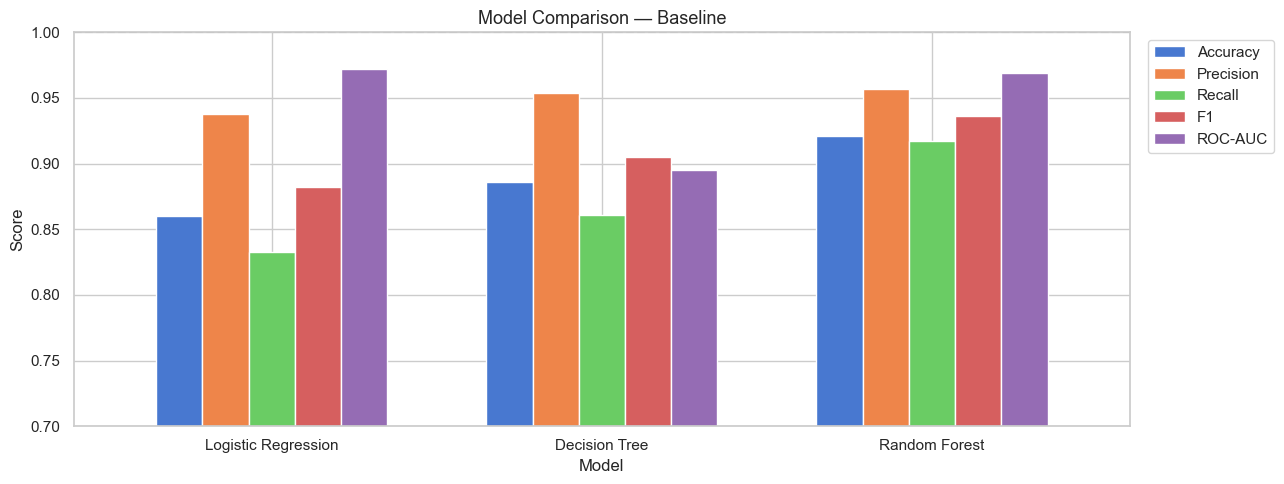

In [28]:
results_df = pd.DataFrame([lr_metrics, dt_metrics, rf_metrics])
results_df = results_df.set_index('Model').round(3)
print(results_df.to_string())

ax = results_df[['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']].plot(
    kind='bar', figsize=(13, 5), width=0.7
)
ax.set_title('Model Comparison — Baseline', fontsize=13)
ax.set_ylabel('Score')
ax.set_ylim(0.7, 1.0)
ax.set_xticklabels(results_df.index, rotation=0)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
ax.axhline(1.0, color='gray', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

### Confusion Matrices — All Three Models

Each cell shows: **Actual (row) vs Predicted (column)**  
We want the off-diagonal (errors) to be as small as possible, especially the **bottom-left** (Malignant predicted as Benign).

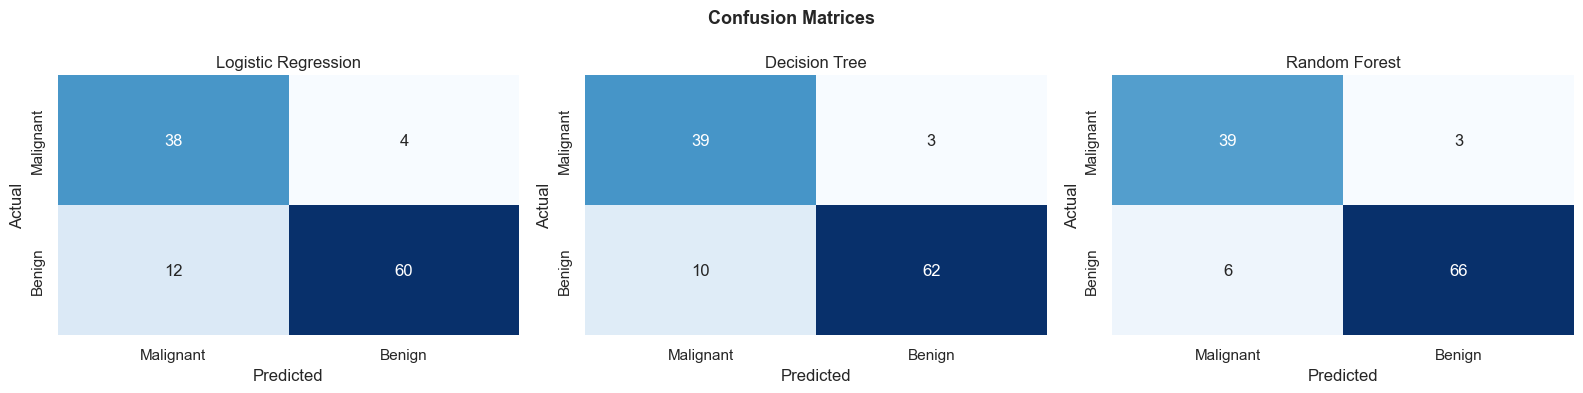

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
labels = ['Malignant', 'Benign']
model_preds = [
    ('Logistic Regression', y_pred_lr),
    ('Decision Tree',       y_pred_dt),
    ('Random Forest',       y_pred_rf)
]

for ax, (name, y_pred) in zip(axes, model_preds):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=labels, yticklabels=labels, cbar=False)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7. Hyperparameter Tuning

The default Decision Tree tends to overfit (grows too deep). The default Random Forest is already decent.  
We tune both using the two search strategies.

### 7.1 Decision Tree — GridSearchCV

We limit `max_depth` to prevent overfitting, and try different split criteria.  
We use `scoring='recall'` because catching all Malignant cases is the priority.

In [30]:
dt_param_grid = {
    'clf__max_depth':        [3, 5, 7, 10, None],
    'clf__min_samples_split': [2, 5, 10, 20],
    'clf__criterion':        ['gini', 'entropy']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

dt_grid = GridSearchCV(
    dt_pipe,
    dt_param_grid,
    cv=cv,
    scoring='recall',
    verbose=1,
    n_jobs=-1
)
dt_grid.fit(X_train, y_train)

print('Best params (Decision Tree Grid):', dt_grid.best_params_)
print(f'Best CV Recall: {dt_grid.best_score_:.3f}')

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best params (Decision Tree Grid): {'clf__criterion': 'gini', 'clf__max_depth': 5, 'clf__min_samples_split': 2}
Best CV Recall: 0.940


              precision    recall  f1-score   support

   Malignant       0.74      0.93      0.82        42
      Benign       0.95      0.81      0.87        72

    accuracy                           0.85       114
   macro avg       0.84      0.87      0.85       114
weighted avg       0.87      0.85      0.85       114



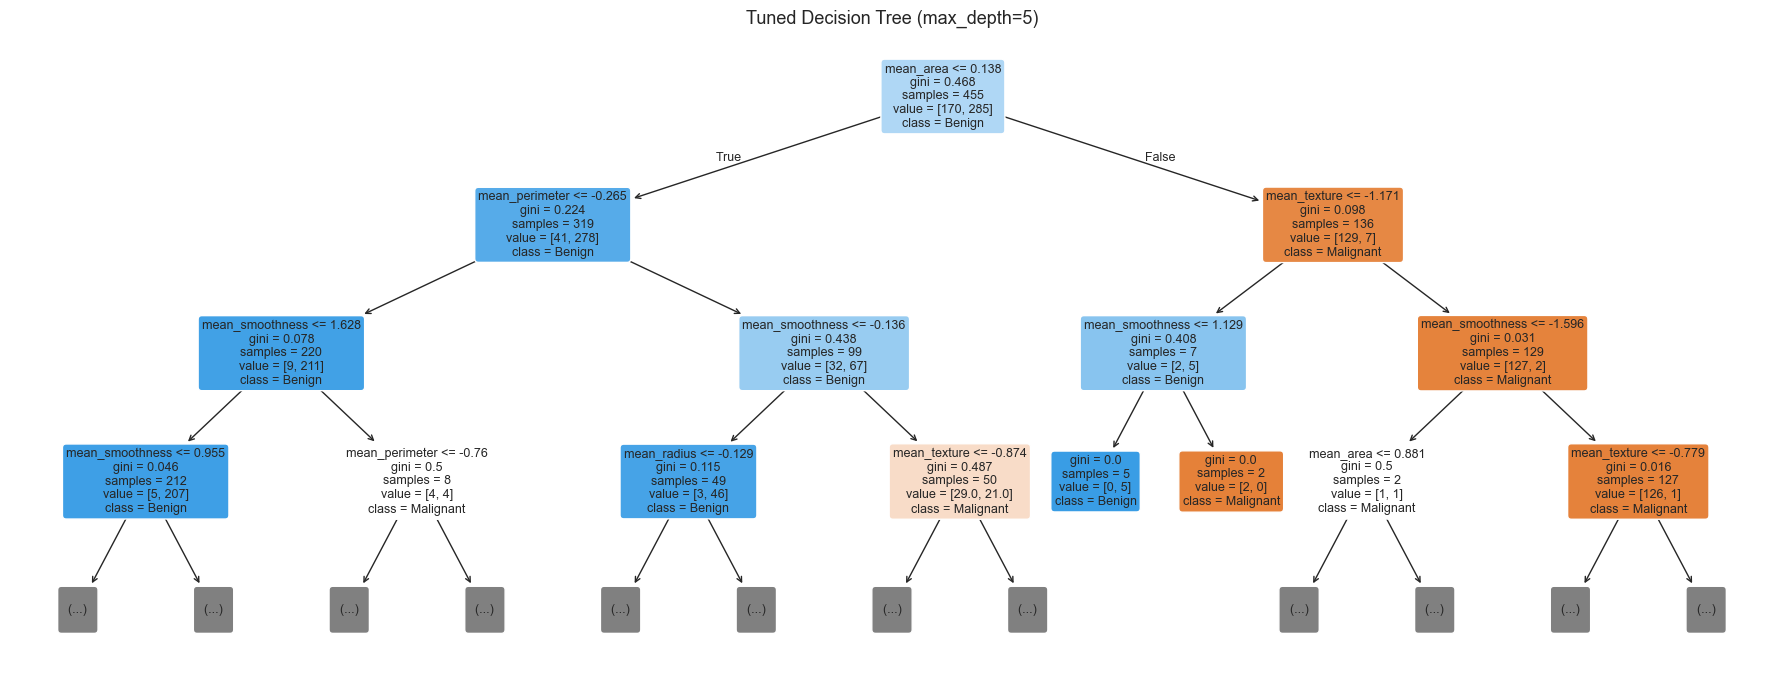

In [31]:
y_pred_dt_tuned = dt_grid.predict(X_test)
y_prob_dt_tuned = dt_grid.predict_proba(X_test)[:, 1]

dt_tuned_metrics = {
    'Model':     'Decision Tree (tuned)',
    'Accuracy':  accuracy_score(y_test, y_pred_dt_tuned),
    'Precision': precision_score(y_test, y_pred_dt_tuned),
    'Recall':    recall_score(y_test, y_pred_dt_tuned),
    'F1':        f1_score(y_test, y_pred_dt_tuned),
    'ROC-AUC':   roc_auc_score(y_test, y_prob_dt_tuned)
}
print(classification_report(y_test, y_pred_dt_tuned, target_names=['Malignant', 'Benign']))

# Visualise the tuned (shallower) tree — much more readable
fig, ax = plt.subplots(figsize=(18, 7))
plot_tree(
    dt_grid.best_estimator_.named_steps['clf'],
    feature_names=features,
    class_names=['Malignant', 'Benign'],
    filled=True, rounded=True, max_depth=3, ax=ax, fontsize=9
)
plt.title(f"Tuned Decision Tree (max_depth={dt_grid.best_params_['clf__max_depth']})", fontsize=13)
plt.tight_layout()
plt.show()

### 7.2 Random Forest — RandomizedSearchCV

Random Forest has many hyperparameters — RandomizedSearch explores a larger space efficiently.

In [32]:
from scipy.stats import randint

rf_param_dist = {
    'clf__n_estimators':      randint(50, 400),
    'clf__max_depth':         [None, 5, 10, 15, 20],
    'clf__min_samples_split': randint(2, 20),
    'clf__min_samples_leaf':  randint(1, 10),
    'clf__max_features':      ['sqrt', 'log2', None]
}

rf_rand = RandomizedSearchCV(
    rf_pipe,
    rf_param_dist,
    n_iter=30,
    cv=cv,
    scoring='recall',
    verbose=1,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_rand.fit(X_train, y_train)

print('Best params (RF Random):', rf_rand.best_params_)
print(f'Best CV Recall: {rf_rand.best_score_:.3f}')

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params (RF Random): {'clf__max_depth': 5, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 7, 'clf__min_samples_split': 10, 'clf__n_estimators': 377}
Best CV Recall: 0.972


In [33]:
y_pred_rf_tuned = rf_rand.predict(X_test)
y_prob_rf_tuned = rf_rand.predict_proba(X_test)[:, 1]

rf_tuned_metrics = {
    'Model':     'RF (tuned Random)',
    'Accuracy':  accuracy_score(y_test, y_pred_rf_tuned),
    'Precision': precision_score(y_test, y_pred_rf_tuned),
    'Recall':    recall_score(y_test, y_pred_rf_tuned),
    'F1':        f1_score(y_test, y_pred_rf_tuned),
    'ROC-AUC':   roc_auc_score(y_test, y_prob_rf_tuned)
}
print(classification_report(y_test, y_pred_rf_tuned, target_names=['Malignant', 'Benign']))

              precision    recall  f1-score   support

   Malignant       0.88      0.90      0.89        42
      Benign       0.94      0.93      0.94        72

    accuracy                           0.92       114
   macro avg       0.91      0.92      0.92       114
weighted avg       0.92      0.92      0.92       114



---
## 8. ROC Curves — All Models

The **ROC curve** plots Recall (True Positive Rate) vs False Positive Rate at every threshold.  
**AUC closer to 1.0** = better overall separation between classes.  
The diagonal line = a random classifier (AUC = 0.5).

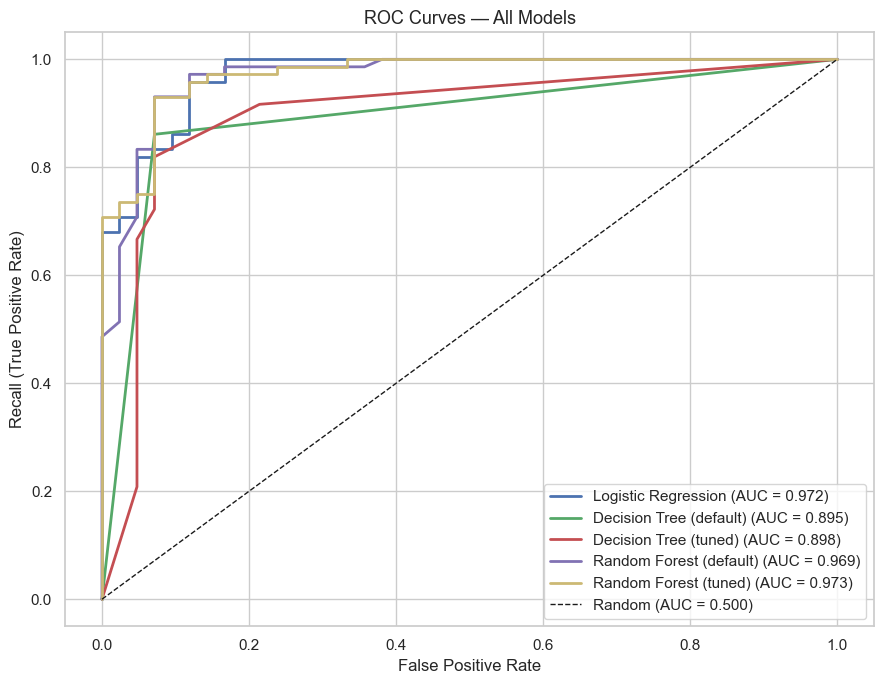

In [34]:
plt.figure(figsize=(9, 7))

roc_models = [
    ('Logistic Regression',        y_prob_lr,        '#4C72B0'),
    ('Decision Tree (default)',    y_prob_dt,        '#55A868'),
    ('Decision Tree (tuned)',      y_prob_dt_tuned,  '#C44E52'),
    ('Random Forest (default)',    y_prob_rf,        '#8172B3'),
    ('Random Forest (tuned)',      y_prob_rf_tuned,  '#CCB974'),
]

for name, y_prob, color in roc_models:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.500)')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('Recall (True Positive Rate)', fontsize=12)
plt.title('ROC Curves — All Models', fontsize=13)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

---
## 9. Final Model Comparison Table

=== Final Results ===
                       Accuracy  Precision  Recall     F1  ROC-AUC
Model                                                             
RF (tuned Random)         0.921      0.944   0.931  0.937    0.973
Random Forest             0.921      0.957   0.917  0.936    0.969
Decision Tree             0.886      0.954   0.861  0.905    0.895
Logistic Regression       0.860      0.938   0.833  0.882    0.972
Decision Tree (tuned)     0.851      0.951   0.806  0.872    0.898


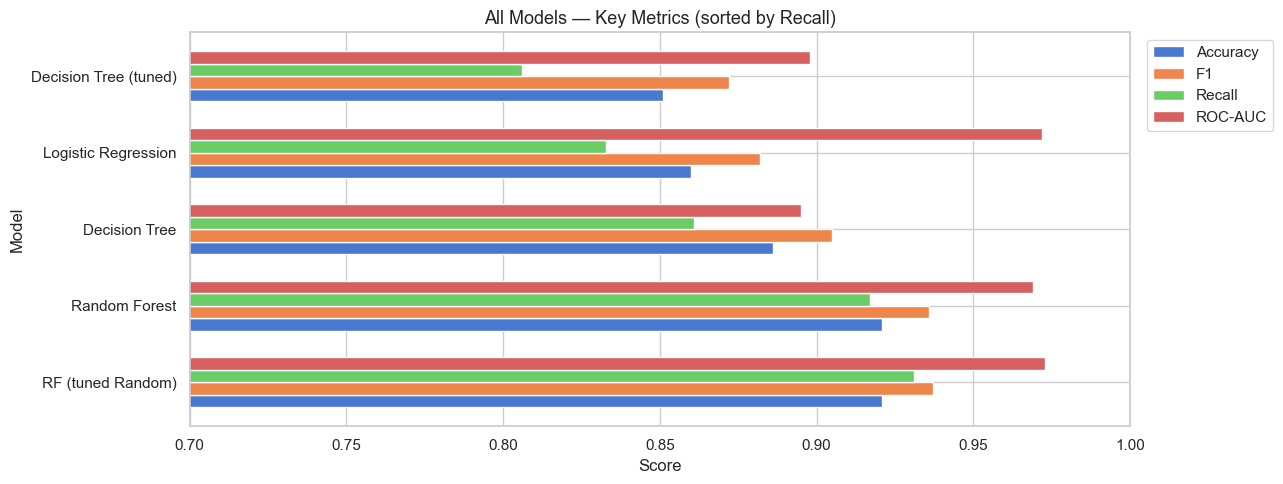

In [35]:
all_results = pd.DataFrame([
    lr_metrics, dt_metrics, rf_metrics, dt_tuned_metrics, rf_tuned_metrics
]).set_index('Model').round(3)

print('=== Final Results ===')
print(all_results.sort_values('Recall', ascending=False).to_string())

all_results.sort_values('Recall', ascending=False)[['Accuracy', 'F1', 'Recall', 'ROC-AUC']].plot(
    kind='barh', figsize=(13, 5), width=0.65
)
plt.title('All Models — Key Metrics (sorted by Recall)', fontsize=13)
plt.xlabel('Score')
plt.xlim(0.7, 1.0)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

---
## 10. Feature Importance

Random Forest tells us which features drove the most splits.

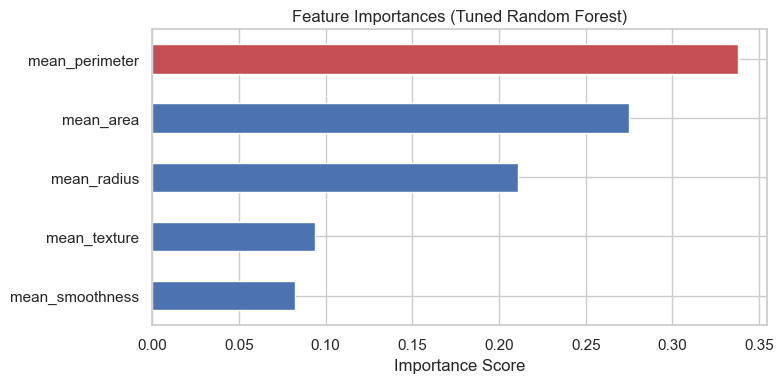

Most important feature: mean_perimeter


In [36]:
best_rf_clf = rf_rand.best_estimator_.named_steps['clf']
importances = pd.Series(best_rf_clf.feature_importances_, index=features).sort_values(ascending=True)

plt.figure(figsize=(8, 4))
colors = ['#C44E52' if v == importances.max() else '#4C72B0' for v in importances.values]
importances.plot(kind='barh', color=colors)
plt.title('Feature Importances (Tuned Random Forest)', fontsize=12)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('Most important feature:', importances.idxmax())